In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

import json

import matplotlib.pyplot as plt
import seaborn as sns

import itertools

# DeepONet Functions

## Data

In [50]:
class MazeDataset(Dataset):
    """
    Custom PyTorch Dataset for the Cognitive DeepONet.
    """
    def __init__(self, trial_features, participant_ids, choices):
        """
        trial_features: numpy array or tensor of shape [N, 3] (Tier1, Tier2, Drift)
        participant_ids: numpy array or tensor of shape [N] (Integer IDs starting from 0)
        choices: numpy array or tensor of shape [N] (0 for Left, 1 for Right)
        """
        self.features = torch.tensor(trial_features, dtype=torch.float32)
        self.p_ids = torch.tensor(participant_ids, dtype=torch.long)
        
        # BCEWithLogitsLoss requires target labels to be floats
        self.choices = torch.tensor(choices, dtype=torch.float32)

    def __len__(self):
        return len(self.choices)

    def __getitem__(self, idx):
        return self.features[idx], self.p_ids[idx], self.choices[idx]

## DeepONet architecture

In [51]:
class CognitiveDeepONet(nn.Module):
    def __init__(self, num_participants, num_features=3, num_bases=4):
        super().__init__()
        
        # The Universal Trunk (Basis Functions)
        self.basis_net = nn.Sequential(
            nn.Linear(num_features, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, num_bases),
            nn.Tanh()  # <--- Forces all bases into the exact same [-1, 1] scale
        )
        
        # The Branch (Participant Coefficients)
        self.participant_coeffs = nn.Embedding(num_embeddings=num_participants, 
                                               embedding_dim=num_bases)
        
        # Initialize embeddings around 0 to prevent extreme initial predictions
        nn.init.normal_(self.participant_coeffs.weight, mean=0.0, std=0.1)

    def forward(self, trial_features, participant_ids):
        # 1. Evaluate universal bases [batch_size, num_bases]
        bases = self.basis_net(trial_features)
        
        # 2. Lookup individual coefficients [batch_size, num_bases]
        coeffs = self.participant_coeffs(participant_ids)
        
        # 3. Dot product to get final prediction logits [batch_size]
        logits = torch.sum(bases * coeffs, dim=1)
        
        return logits, bases

## Orthogonal Bases

In [52]:
def orthogonality_penalty(bases):
    """
    Forces the basis functions to be independent/orthogonal across the batch.
    """
    # Normalize the bases along the batch dimension
    bases_norm = F.normalize(bases, p=2, dim=0)
    
    # Compute correlation matrix (should theoretically be an identity matrix)
    correlation_matrix = torch.matmul(bases_norm.T, bases_norm)
    
    # Create the target Identity matrix
    identity = torch.eye(correlation_matrix.size(0), device=bases.device)
    
    # Penalty is the Frobenius norm of the difference
    penalty = torch.norm(correlation_matrix - identity, p='fro')
    return penalty

## Training Function

In [53]:
def train_deeponet(model, dataloader, num_epochs=50, lr=0.001, penalty_weight=0.1):
    """
    Main training function.
    penalty_weight: How strictly to enforce the orthogonality penalty (lambda)
    """
    # Standard classification loss for binary choice (Left vs Right)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    
    for epoch in range(num_epochs):
        total_loss = 0.0
        total_bce = 0.0
        total_orth = 0.0
        
        for features, p_ids, true_choices in dataloader:
            optimizer.zero_grad()
            
            # Forward pass
            logits, bases = model(features, p_ids)
            
            # Calculate Losses
            bce_loss = criterion(logits, true_choices)
            orth_loss = orthogonality_penalty(bases)
            
            # Combine losses
            loss = bce_loss + (penalty_weight * orth_loss)
            
            # Backpropagation
            loss.backward()
            optimizer.step()
            
            # Logging
            total_loss += loss.item()
            total_bce += bce_loss.item()
            total_orth += orth_loss.item()
            
        # Print progress every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            avg_loss = total_loss / len(dataloader)
            avg_bce = total_bce / len(dataloader)
            avg_orth = total_orth / len(dataloader)
            
            print(f"Epoch {epoch+1:03d}/{num_epochs} | "
                  f"Total Loss: {avg_loss:.4f} | "
                  f"BCE: {avg_bce:.4f} | "
                  f"Orth Penalty: {avg_orth:.4f}")

    return model

In [54]:
def load(fnm):
	return json.load(open(fnm))

def pre_proccess_data_from_choice_vs_no_choice(data):
    output = []

    for block_num, block in enumerate(data['blocks']):
        if block_num == 0:
            continue

        try:
            block_drift = block['block_config']['params']['startCameraMode']
        except (KeyError, TypeError):
            block_drift = 0

        game_states = block.get('game_states', {})
        state_times = np.array(game_states.get('time', []))
        ball_y_coords = np.array(game_states.get('ball_y', []))
        camera_y_coords = np.array(game_states.get('camera_y', []))
        
        trials = block['trials']

        for i in range(len(trials) // 3):
            try:
                tier1_event_time = trials[3*i]['events'][0]['time']
                
                if len(state_times) > 0:

                    closest_state_idx = np.abs(state_times - tier1_event_time).argmin()
                    relative_ball_y = float(ball_y_coords[closest_state_idx] - camera_y_coords[closest_state_idx])
                else:
                    relative_ball_y = None


                choice_trial_sequence = [
                    trials[3*i]['hole_locations'],
                    trials[3*i+1]['hole_locations'],
                    trials[3*i+2]['hole_locations']
                ]
                
                chosen_path = [
                    trials[3*i]['events'][0]['holeUsed'], 
                    trials[3*i+1]['events'][0]['holeUsed'],
                    trials[3*i+2]['events'][0]['holeUsed']
                ]
                
                observed_rt = trials[3*i+2]['events'][0]['time'] - trials[3*i]['events'][0]['time']
                
                # does the middle trial have two options
                is_choice = len(trials[3*i+1]['hole_locations']) == 2

                if is_choice:
                    options = trials[3*i+1]['hole_locations']
                    chosen_hole = trials[3*i+1]['events'][0]['holeUsed']
                    
                    unchosen_hole = options[0] if options[0] != chosen_hole else options[1]
                    
                    non_chosen_path = [
                        trials[3*i]['events'][0]['holeUsed'], 
                        unchosen_hole, 
                        trials[3*i+2]['events'][0]['holeUsed']
                    ]
                    
                    chosen_1step_dist = abs(chosen_path[1] - chosen_path[0])
                    unchosen_1step_dist = abs(non_chosen_path[1] - non_chosen_path[0])
                    
                    chosen_2step_dist = chosen_1step_dist + abs(chosen_path[2] - chosen_path[1])
                    unchosen_2step_dist = unchosen_1step_dist + abs(non_chosen_path[2] - non_chosen_path[1])
                    
                else:
                    non_chosen_path = None
                    chosen_1step_dist = None
                    unchosen_1step_dist = None
                    chosen_2step_dist = None
                    unchosen_2step_dist = None
                
                output.append({
                    'block_number': block_num,
                    'trial_sequence_number': i,
                    'hole_sequence': choice_trial_sequence,
                    'chosen_path': chosen_path,
                    'non_chosen_path': non_chosen_path,
                    'observed_rt': observed_rt,
                    'choice_trial': is_choice,
                    'chosen_1step_dist': chosen_1step_dist,
                    'unchosen_1step_dist': unchosen_1step_dist,
                    'chosen_2step_dist': chosen_2step_dist,
                    'unchosen_2step_dist': unchosen_2step_dist,
                    'block_drift': block_drift,
                    'ball_y_at_top': relative_ball_y
                })
            except (KeyError, IndexError, TypeError) as e:
                continue

    output = pd.DataFrame(output)

    Q1 = output['observed_rt'].quantile(0.25)
    Q3 = output['observed_rt'].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 2.5 * IQR
    upper_bound = Q3 + 2.5 * IQR
    
    output = output[(output['observed_rt'] >= lower_bound) & (output['observed_rt'] <= upper_bound)]
    output = output.reset_index(drop=True)

    chosen_middle = output['chosen_path'].str[1]
    unchosen_middle = output['non_chosen_path'].str[1]
    output['chosen_left'] = (chosen_middle < unchosen_middle)

    prev_end_hole = output['chosen_path'].shift(1).str[2]
    curr_start_hole = output['chosen_path'].str[0]
    direction = np.sign(prev_end_hole - curr_start_hole)

    prev_seq_num = output['trial_sequence_number'].shift(1)
    curr_seq_num = output['trial_sequence_number']

    prev_block = output['block_number'].shift(1)
    curr_block = output['block_number']

    is_valid_sequence = (prev_seq_num + 1 == curr_seq_num) & (prev_block == curr_block)

    output['incoming_direction'] = np.where(is_valid_sequence, -direction, np.nan)

    output = output.dropna(subset=['incoming_direction']).reset_index(drop=True)

    return output

def build_deeponet_dataset(participant_data_dict):
    all_features = []
    all_choices = []
    all_p_ids = []
    
    for p_idx, (participant_name, raw_data) in enumerate(participant_data_dict.items()):
        
        # 1. Run pre-processing
        processed_data = pre_proccess_data_from_choice_vs_no_choice(raw_data)
        
        # Drop all non-choice trials and any accidental NaNs
        # (Updated dropna to check 'ball_y_at_top' instead of 'block_drift')
        processed_data = processed_data[processed_data['choice_trial'] == True]
        processed_data = processed_data.dropna(subset=['chosen_1step_dist', 'ball_y_at_top'])
        processed_data = processed_data.reset_index(drop=True)
        
        # 2. Extract clean intermediate arrays for Left vs Right
        is_left = processed_data['chosen_left']
        
        # L1 and R1
        L1 = np.where(is_left, processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist'])
        R1 = np.where(~is_left, processed_data['chosen_1step_dist'], processed_data['unchosen_1step_dist'])
        
        # Total L (L1 + L2) and Total R (R1 + R2)
        # Your pre-processing function already calculated 2step_dist as the cumulative total distance
        Total_L = np.where(is_left, processed_data['chosen_2step_dist'], processed_data['unchosen_2step_dist'])
        Total_R = np.where(~is_left, processed_data['chosen_2step_dist'], processed_data['unchosen_2step_dist'])
        
        # 3. Build your feature DataFrame with the new difference metrics
        X = pd.DataFrame({
            'L1_minus_R1': L1 - R1,
            'Total_L_minus_Total_R': Total_L - Total_R,
            'ball_y_at_top': processed_data['ball_y_at_top'],
            'incoming_direction': processed_data['incoming_direction']
        })
        
        # 4. Convert to DeepONet Inputs
        features = X.values 
        choices = (~processed_data['chosen_left']).astype(float).values
        p_ids = np.full(len(processed_data), p_idx)
        
        # 5. Append to master lists
        all_features.append(features)
        all_choices.append(choices)
        all_p_ids.append(p_ids)

    final_features = np.vstack(all_features)
    final_p_ids = np.concatenate(all_p_ids)
    final_choices = np.concatenate(all_choices)
    
    return final_features, final_p_ids, final_choices, len(participant_data_dict)

In [55]:
def evaluate_deeponet(model, dataloader):
    """
    Evaluates the model on a given dataset (Test or Train).
    Calculates Accuracy and Log-Likelihood.
    """
    model.eval() # Put model in evaluation mode (disables dropout, etc.)
    
    total_ll = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # Disable gradient calculation for faster, memory-efficient inference
    with torch.no_grad():
        for features, p_ids, true_choices in dataloader:
            
            # Forward pass
            logits, bases = model(features, p_ids)
            
            # 1. Calculate Log-Likelihood
            # BCEWithLogitsLoss with reduction='sum' is exactly the negative Log-Likelihood
            bce_sum = F.binary_cross_entropy_with_logits(logits, true_choices, reduction='sum')
            total_ll += -bce_sum.item()
            
            # 2. Calculate Accuracy
            # Convert logits to probabilities, then to 0 or 1 predictions
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).float()
            
            correct_predictions += (predictions == true_choices).sum().item()
            total_samples += true_choices.size(0)
            
    avg_ll = total_ll / total_samples
    accuracy = correct_predictions / total_samples
    
    print(f"--- Evaluation Metrics ---")
    print(f"Total Log-Likelihood:   {total_ll:.4f}")
    print(f"Average Log-Likelihood: {avg_ll:.4f}")
    print(f"Accuracy:               {accuracy * 100:.2f}% ({correct_predictions}/{total_samples})")
    print(f"--------------------------\n")
    
    return total_ll, accuracy


In [56]:
participant1 = load("../data/cloud_study/65D6694BE06947289BE4336BC1DE271A-019e9464-b9d3-798d-aa65-c87d82961db6-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-03-48-346Z-fg8d.json")
participant2 = load("../data/cloud_study/88AD64F00C6B43489770A02E7A1AE2C2-019e8fd9-16e9-7876-8e3b-d51a48df0526-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-03T23-37-31-300Z-4ecm.json")
participant3 = load("../data/cloud_study/6462D588260B4356936047A04A336EBE-019e9464-f99c-77c5-bf47-327c7a7cf4f1-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T21-41-26-943Z-c5do.json")
participant4 = load("../data/cloud_study/46331EBA4F494FAD901E83106523FF12-019e9464-9d12-7cc3-8cba-8f0dd00eeb20-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-33-792Z-sop6.json")
participant5 = load("../data/cloud_study/BB4D2ACD4DAB45F5BAB68A472EB2E06C-019e9464-9a85-718c-9964-ec6755cdcd1c-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-17-611Z-i0am.json")
participant6 = load("../data/cloud_study/C47CEEC22AD9448E9F87D0577BA7FC80-019e946e-abeb-723a-8d4d-50881fc0551f-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-59-12-508Z-e1tl.json")
participant7 = load("../data/cloud_study/CEFD2FE92E6847B2B27FF0175811CE81-019e9464-988c-7240-bf66-336f77c05049-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-50-03-371Z-34zm.json")
participant8 = load("../data/cloud_study/EC07396CE23248F2855499612FEB8ACA-019e9464-92a5-7d10-b713-7022c5b049fc-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-48-16-501Z-olib.json")
participant9 = load("../data/cloud_study/FD2A6686546A4D689BE4A684CD264636-019e946a-96b4-78df-ac42-63e6e82c3209-019e8386-74e7-7359-827b-6b4e4bc47db9-2026-06-04T20-54-42-499Z-j7h3.json")

participants_data = [participant1, participant2, participant3, participant4, participant5, participant6, participant7, participant8, participant9]

In [57]:
participant_data_dict = {f"Participant_{i+1}": data for i, data in enumerate(participants_data)}
raw_features, p_ids, choices, num_participants = build_deeponet_dataset(participant_data_dict)

# 2. Perform the Train-Test Split (80% Train, 20% Test)
X_train, X_test, id_train, id_test, y_train, y_test = train_test_split(
    raw_features, p_ids, choices, test_size=0.2, random_state=42
)

# --- THE NEW SCALING LOGIC ---
# Slice the arrays: Columns 0, 1, 2 are continuous. Column 3 is discrete.
X_train_continuous = X_train[:, :3]
X_train_discrete = X_train[:, 3:]  # Using 3: keeps it as a 2D column vector

X_test_continuous = X_test[:, :3]
X_test_discrete = X_test[:, 3:]

# 3. Scale ONLY the continuous features safely
scaler = StandardScaler()
X_train_continuous_scaled = scaler.fit_transform(X_train_continuous)
X_test_continuous_scaled = scaler.transform(X_test_continuous)

# Re-attach the raw discrete column (-1, 0, 1) to the scaled continuous columns
X_train_final = np.hstack((X_train_continuous_scaled, X_train_discrete))
X_test_final = np.hstack((X_test_continuous_scaled, X_test_discrete))
# ------------------------------

# 4. Load them into PyTorch Datasets (using the newly stacked arrays)
train_dataset = MazeDataset(X_train_final, id_train, y_train)
test_dataset = MazeDataset(X_test_final, id_test, y_test)

# Datasets go into DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 5. Initialize the model
model = CognitiveDeepONet(
    num_participants=num_participants, 
    num_features=4, 
    num_bases=4  
)

# 6. Train the model
print("Starting Training...")
trained_model = train_deeponet(model, train_loader, num_epochs=200, lr=0.0015, penalty_weight=0.5)

# 7. Evaluate on the Test Set
print("Evaluating on UNSEEN Test Data...")
test_ll, test_acc = evaluate_deeponet(trained_model, test_loader)

Starting Training...
Epoch 001/200 | Total Loss: 1.1202 | BCE: 0.6904 | Orth Penalty: 0.8596
Epoch 010/200 | Total Loss: 0.7103 | BCE: 0.5797 | Orth Penalty: 0.2611
Epoch 020/200 | Total Loss: 0.5824 | BCE: 0.5096 | Orth Penalty: 0.1456
Epoch 030/200 | Total Loss: 0.5519 | BCE: 0.4986 | Orth Penalty: 0.1066
Epoch 040/200 | Total Loss: 0.5299 | BCE: 0.4915 | Orth Penalty: 0.0769
Epoch 050/200 | Total Loss: 0.5194 | BCE: 0.4891 | Orth Penalty: 0.0607
Epoch 060/200 | Total Loss: 0.5111 | BCE: 0.4868 | Orth Penalty: 0.0487
Epoch 070/200 | Total Loss: 0.5049 | BCE: 0.4848 | Orth Penalty: 0.0401
Epoch 080/200 | Total Loss: 0.4993 | BCE: 0.4830 | Orth Penalty: 0.0327
Epoch 090/200 | Total Loss: 0.5051 | BCE: 0.4822 | Orth Penalty: 0.0458
Epoch 100/200 | Total Loss: 0.4932 | BCE: 0.4808 | Orth Penalty: 0.0248
Epoch 110/200 | Total Loss: 0.4936 | BCE: 0.4799 | Orth Penalty: 0.0275
Epoch 120/200 | Total Loss: 0.4891 | BCE: 0.4793 | Orth Penalty: 0.0196
Epoch 130/200 | Total Loss: 0.4874 | BCE: 0

## Evaluation

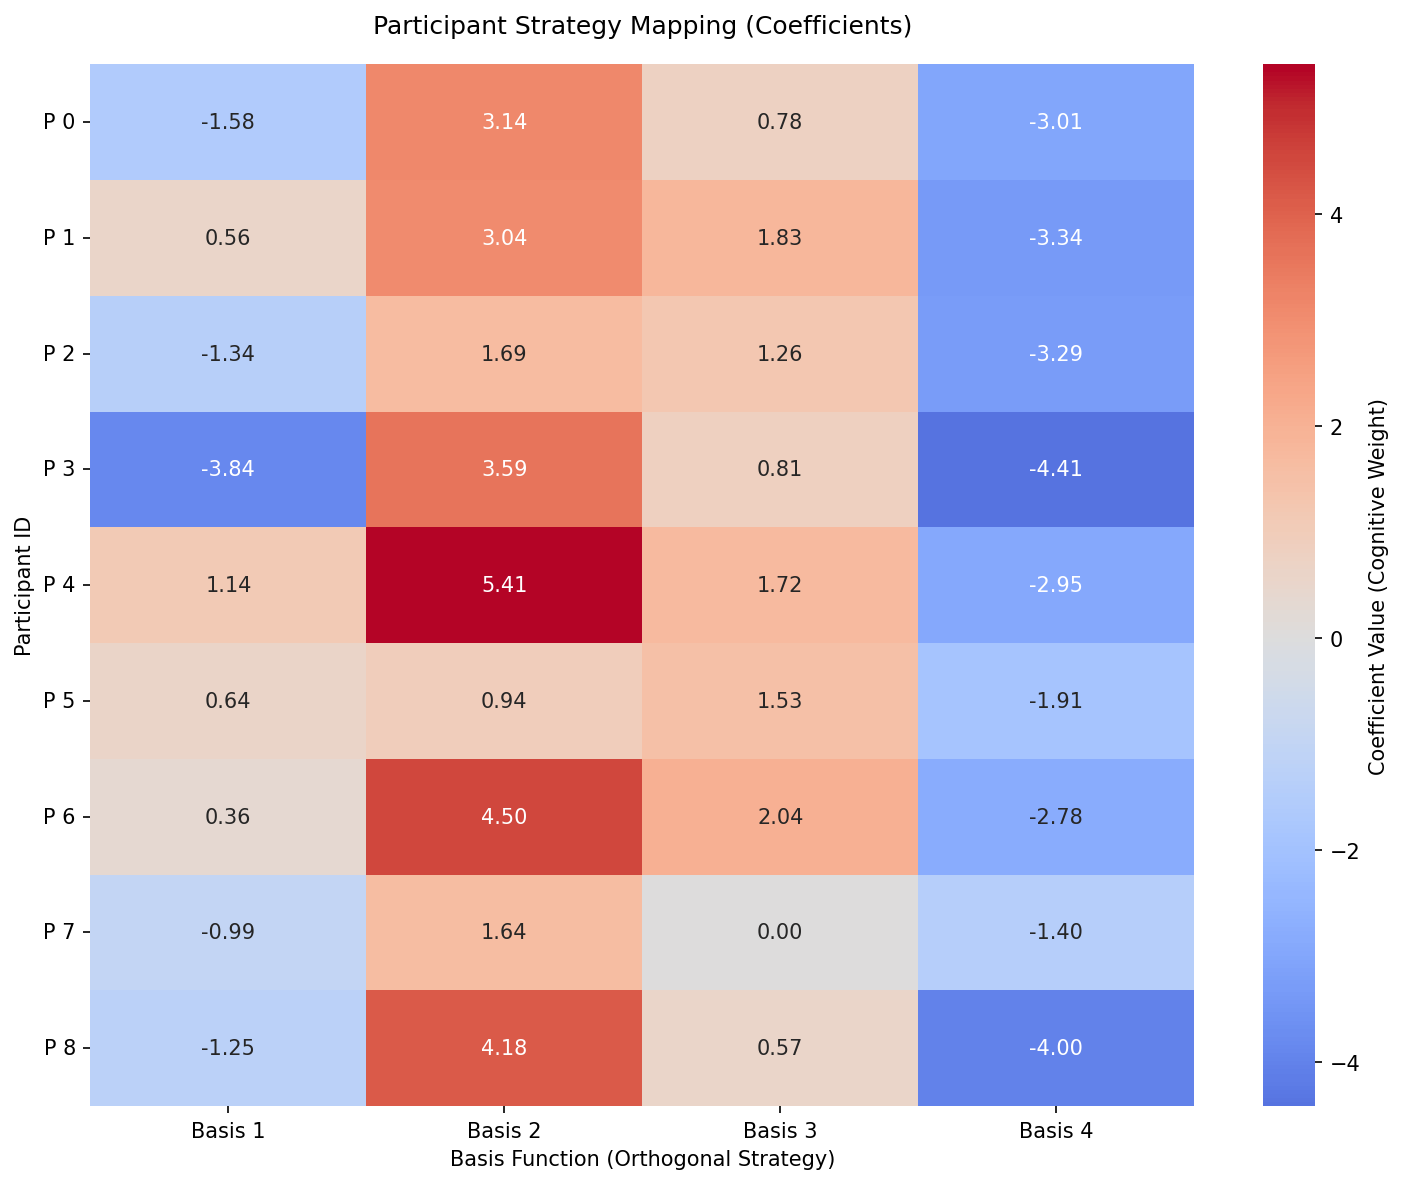

C:\Users\manik\AppData\Local\Temp\ipykernel_93112\3323214579.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_palette = plt.cm.get_cmap('tab10', num_bases)


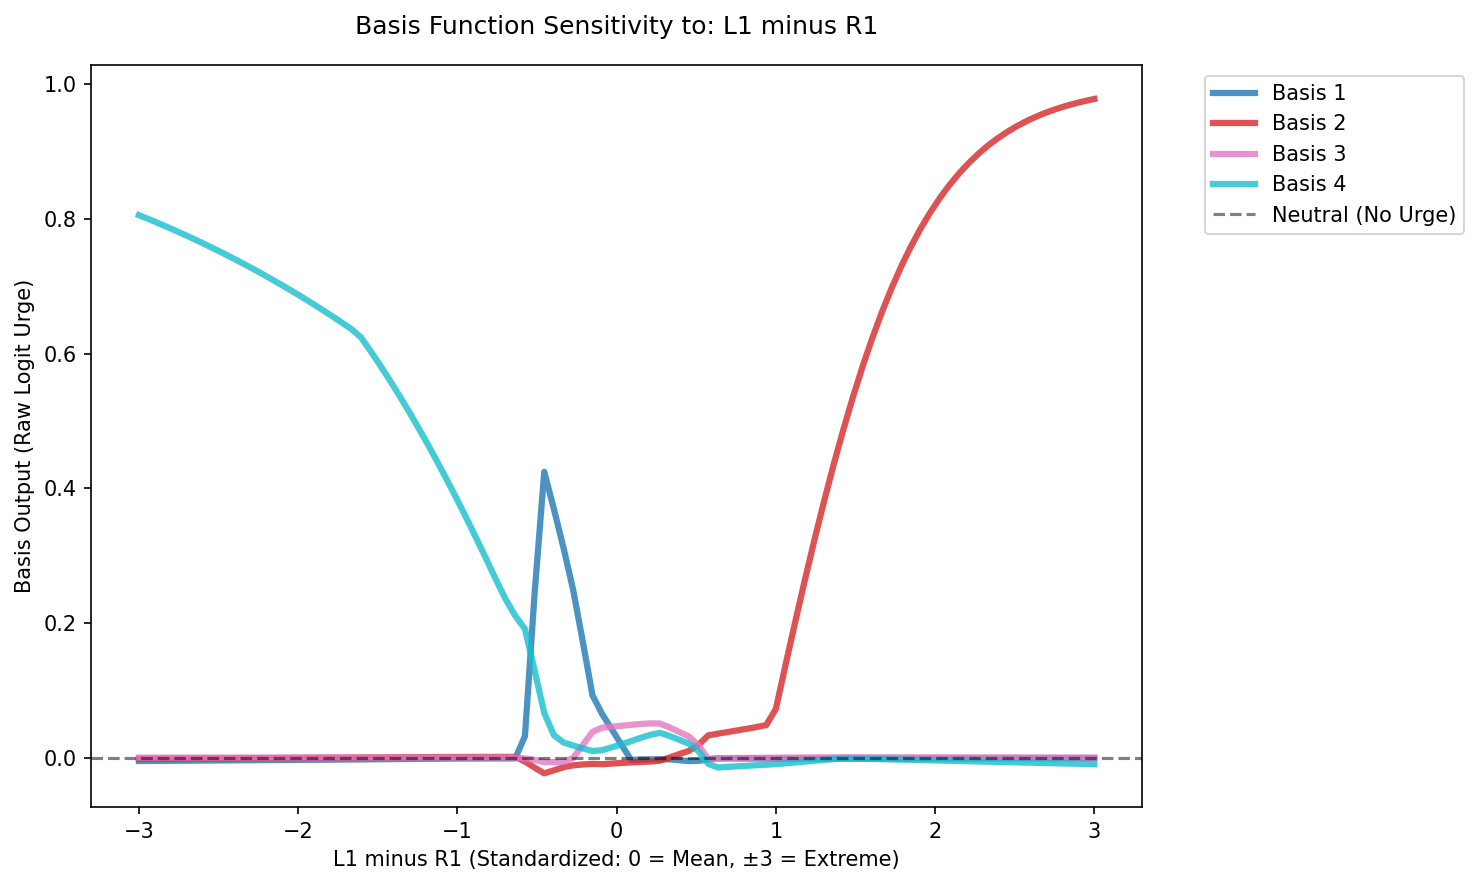

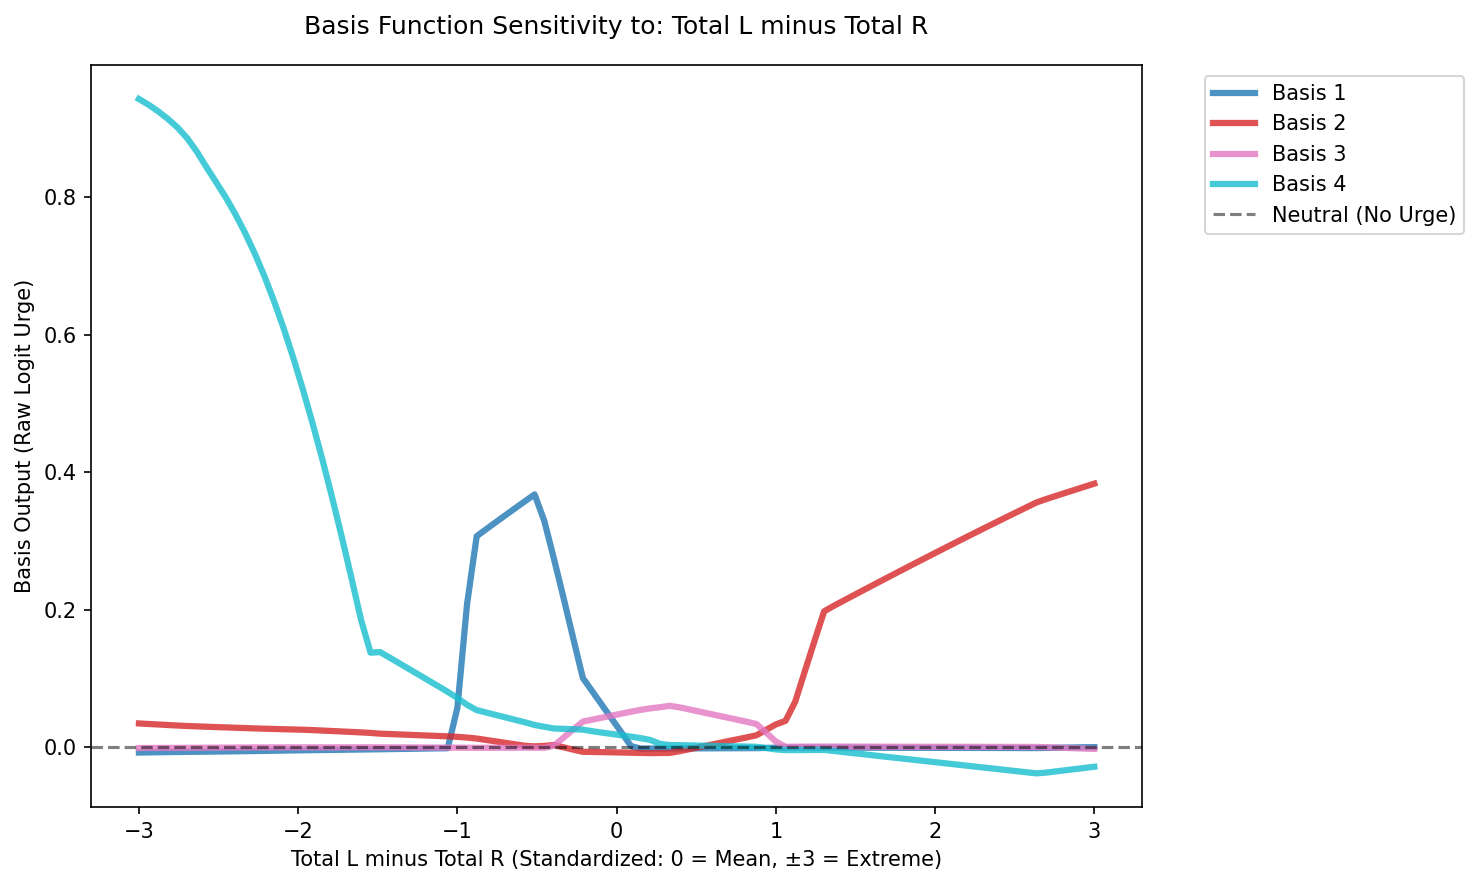

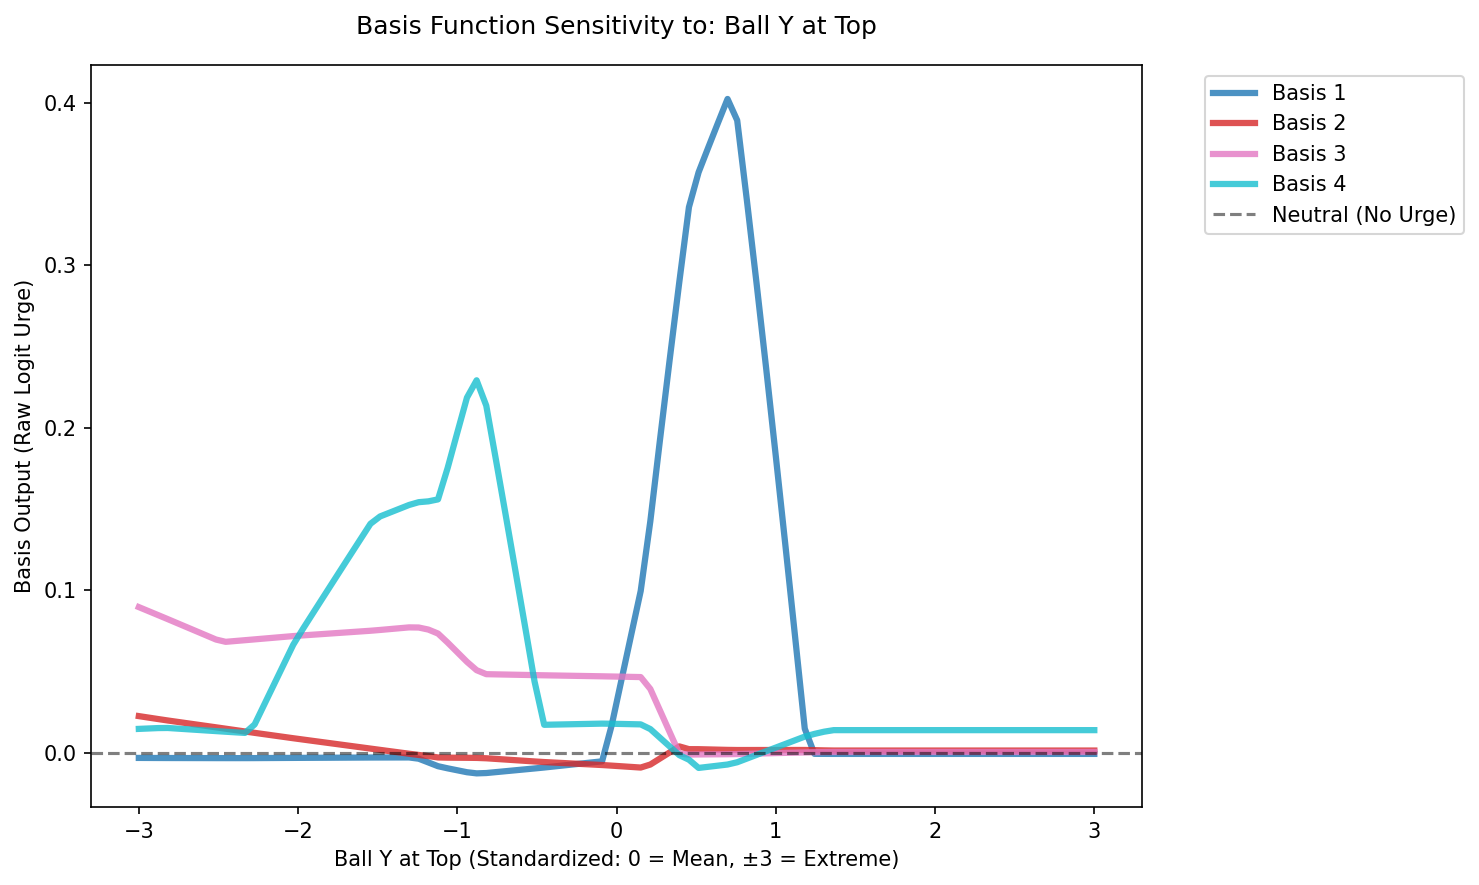

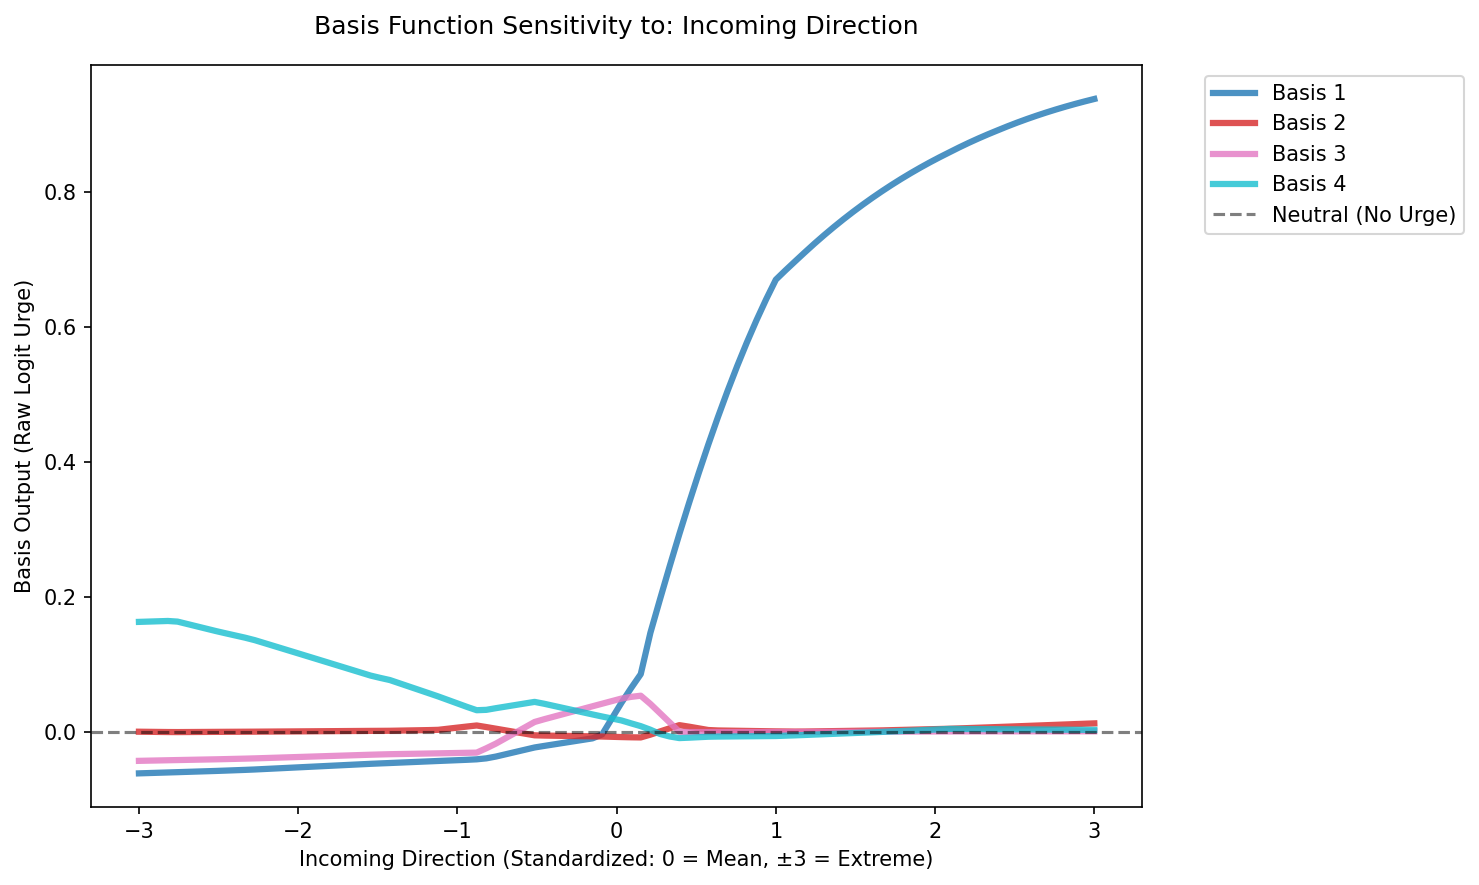

In [58]:
def plot_coefficients_heatmap(model):
    """
    Extracts the embedding weights and plots a heatmap of participant strategies.
    (This function remains unchanged as it is independent of input features)
    """
    coeffs = model.participant_coeffs.weight.detach().cpu().numpy()
    num_participants, num_bases = coeffs.shape
    
    plt.figure(figsize=(10, 8), dpi=150)
    
    ax = sns.heatmap(coeffs, annot=True, fmt=".2f", cmap="coolwarm", center=0, 
                     cbar_kws={'label': 'Coefficient Value (Cognitive Weight)'})
    
    plt.title("Participant Strategy Mapping (Coefficients)", pad=15)
    plt.xlabel("Basis Function (Orthogonal Strategy)")
    plt.ylabel("Participant ID")
    
    ax.set_xticks(np.arange(num_bases) + 0.5)
    ax.set_xticklabels([f"Basis {i+1}" for i in range(num_bases)])
    ax.set_yticks(np.arange(num_participants) + 0.5)
    ax.set_yticklabels([f"P {i}" for i in range(num_participants)], rotation=0)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 2. VISUALIZE BASIS FUNCTIONS (1D SWEEPS)
# ==========================================
def plot_basis_sweep(model, feature_idx=0, feature_name="L1 - R1"):
    """
    Holds all 3 features at 0 (the mean) and sweeps the target feature from -3 to +3
    standard deviations to see how the basis functions react.
    """
    model.eval() 
    
    sweep_values = np.linspace(-3.0, 3.0, 100)
    
    # UPDATED: Dummy input array is now 3 columns wide instead of 5
    dummy_inputs = np.zeros((100, 4))
    
    # Inject our sweep into the specific column we want to test
    dummy_inputs[:, feature_idx] = sweep_values
    
    X_tensor = torch.tensor(dummy_inputs, dtype=torch.float32)
    
    with torch.no_grad():
        bases = model.basis_net(X_tensor).numpy() 
        
    num_bases = bases.shape[1]
    
    plt.figure(figsize=(10, 6), dpi=150)
    
    color_palette = plt.cm.get_cmap('tab10', num_bases)
    
    for i in range(num_bases):
        plt.plot(sweep_values, bases[:, i], label=f"Basis {i+1}", 
                 linewidth=3, alpha=0.8, color=color_palette(i))
        
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (No Urge)')
    
    plt.title(f"Basis Function Sensitivity to: {feature_name}", pad=15)
    plt.xlabel(f"{feature_name} (Standardized: 0 = Mean, ±3 = Extreme)")
    plt.ylabel("Basis Output (Raw Logit Urge)")
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# ==========================================
# EXECUTION EXAMPLES FOR 3 FEATURES
# ==========================================
# 1. Plot the participant heatmap
plot_coefficients_heatmap(trained_model)

# 2. See how bases react to the Tier 1 Advantage changing (Index 0)
# Positive values mean L1 is longer than R1. Negative values mean R1 is longer.
plot_basis_sweep(trained_model, feature_idx=0, feature_name="L1 minus R1")

# 3. See how bases react to the Total Route Advantage changing (Index 1)
plot_basis_sweep(trained_model, feature_idx=1, feature_name="Total L minus Total R")

# 4. See how bases react to the ball's Y position changing (Index 2)
plot_basis_sweep(trained_model, feature_idx=2, feature_name="Ball Y at Top")

plot_basis_sweep(trained_model, feature_idx = 3, feature_name = "Incoming Direction")

In [59]:
def plot_3d_basis_sweeps(model, num_features, feature_names=None):
    """
    Iterates through every possible pair of features. 
    Holds all other features at 0 and sweeps the pair from -3 to +3 to generate 3D surface plots.
    """
    model.eval()
    
    # Auto-generate generic names if none are provided
    if feature_names is None:
        feature_names = [f"Feature {i+1}" for i in range(num_features)]
        
    # 1. Setup the Grid
    grid_resolution = 50  # 50x50 = 2500 points per plot (good balance of speed and smoothness)
    sweep_1d = np.linspace(-3.0, 3.0, grid_resolution)
    
    # Create the 2D coordinate matrices
    X_grid, Y_grid = np.meshgrid(sweep_1d, sweep_1d)
    
    # Flatten the grids so they can be fed into the neural network
    flat_X = X_grid.flatten()
    flat_Y = Y_grid.flatten()
    
    # 2. Get all unique pairs of features (e.g., (0,1), (0,2), (1,2))
    feature_pairs = list(itertools.combinations(range(num_features), 2))
    
    # Do a quick dummy pass to dynamically find out how many basis functions the model has
    with torch.no_grad():
        dummy_test = torch.zeros((1, num_features))
        num_bases = model.basis_net(dummy_test).shape[1]

    # 3. Iterate over every pair and plot
    for f1_idx, f2_idx in feature_pairs:
        
        # Create dummy inputs [2500 rows, num_features columns] initialized to 0
        dummy_inputs = np.zeros((grid_resolution * grid_resolution, num_features))
        
        # Inject our flattened grid into the specific feature columns we are testing
        dummy_inputs[:, f1_idx] = flat_X
        dummy_inputs[:, f2_idx] = flat_Y
        
        X_tensor = torch.tensor(dummy_inputs, dtype=torch.float32)
        
        # Pass through the basis network
        with torch.no_grad():
            bases = model.basis_net(X_tensor).numpy() 
            
        # Create a new figure for this specific feature pair
        # Width scales automatically based on how many basis functions you have
        fig = plt.figure(figsize=(5 * num_bases, 5), dpi=150)
        fig.suptitle(f"Interaction: {feature_names[f1_idx]} vs {feature_names[f2_idx]}", fontsize=14, fontweight='bold')
        
        # Plot a 3D surface for each basis function
        for b_idx in range(num_bases):
            ax = fig.add_subplot(1, num_bases, b_idx + 1, projection='3d')
            
            # Reshape the 1D basis output back into the 2D grid shape (50x50)
            Z_grid = bases[:, b_idx].reshape(grid_resolution, grid_resolution)
            
            # Draw the surface
            # 'viridis' or 'coolwarm' are great colormaps for 3D surfaces
            surf = ax.plot_surface(X_grid, Y_grid, Z_grid, cmap='viridis', edgecolor='none', alpha=0.9)
            
            # Formatting
            ax.set_title(f"Basis {b_idx + 1}")
            ax.set_xlabel(feature_names[f1_idx])
            ax.set_ylabel(feature_names[f2_idx])
            ax.set_zlabel("Basis Output")
            
            # Rotate the 3D view slightly for better visibility
            ax.view_init(elev=25, azim=-45)

        plt.tight_layout()
        plt.show()


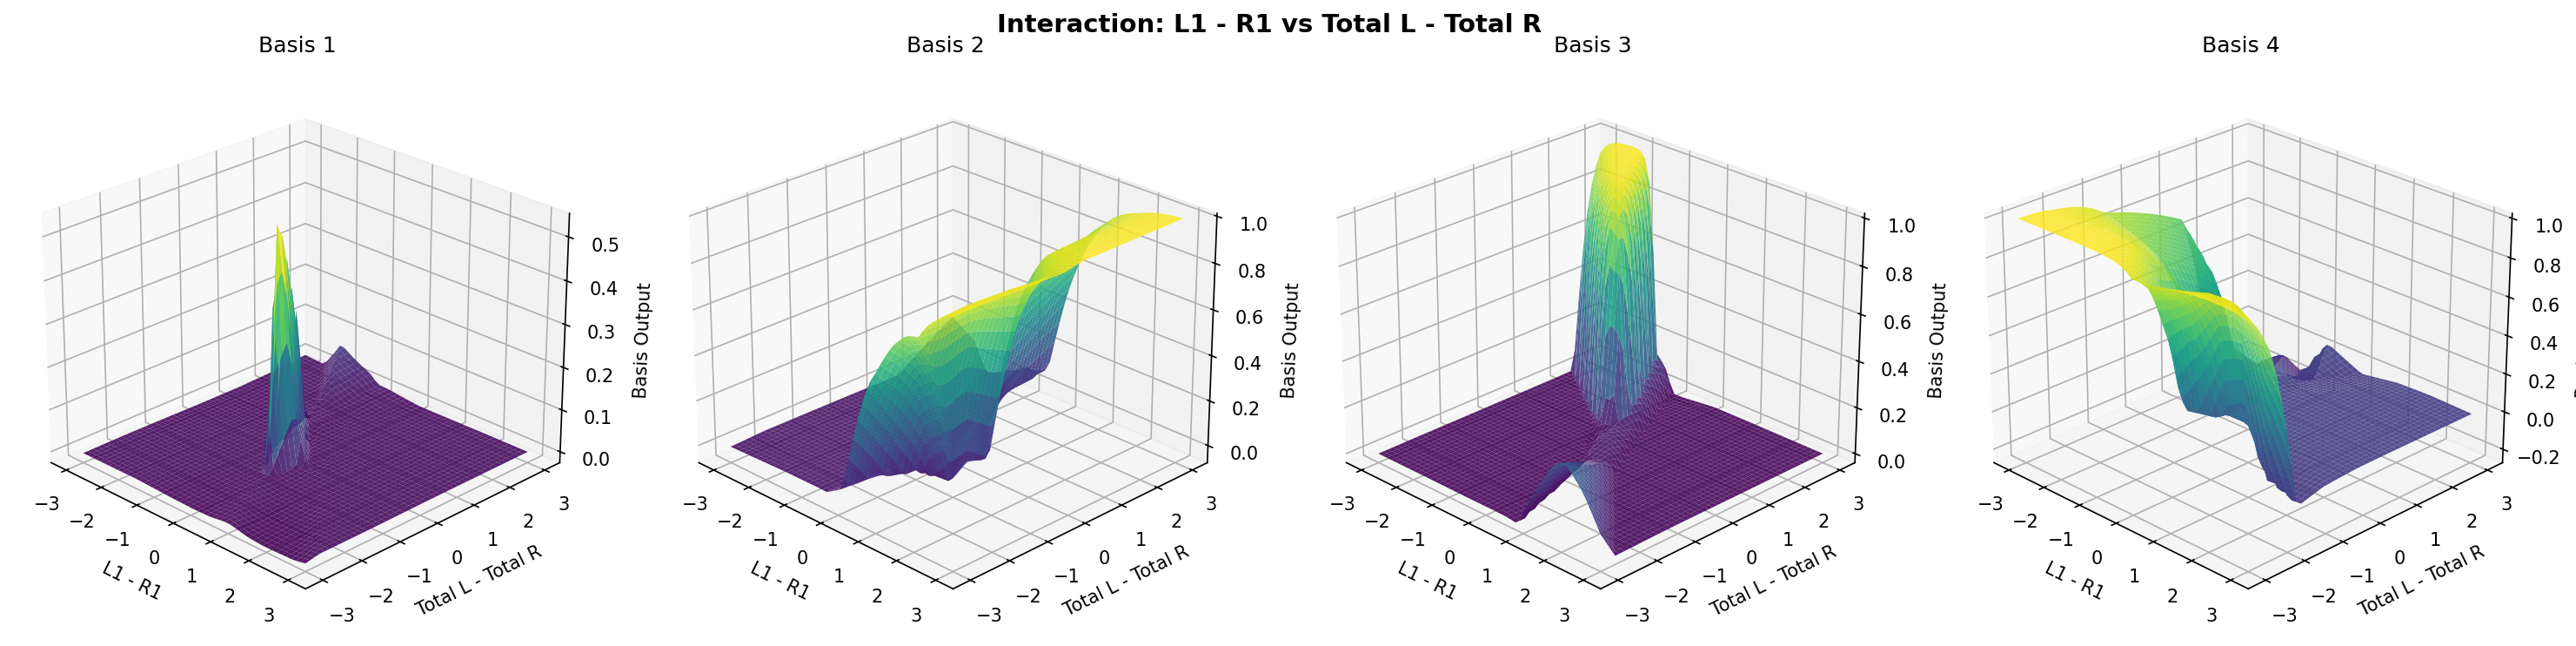

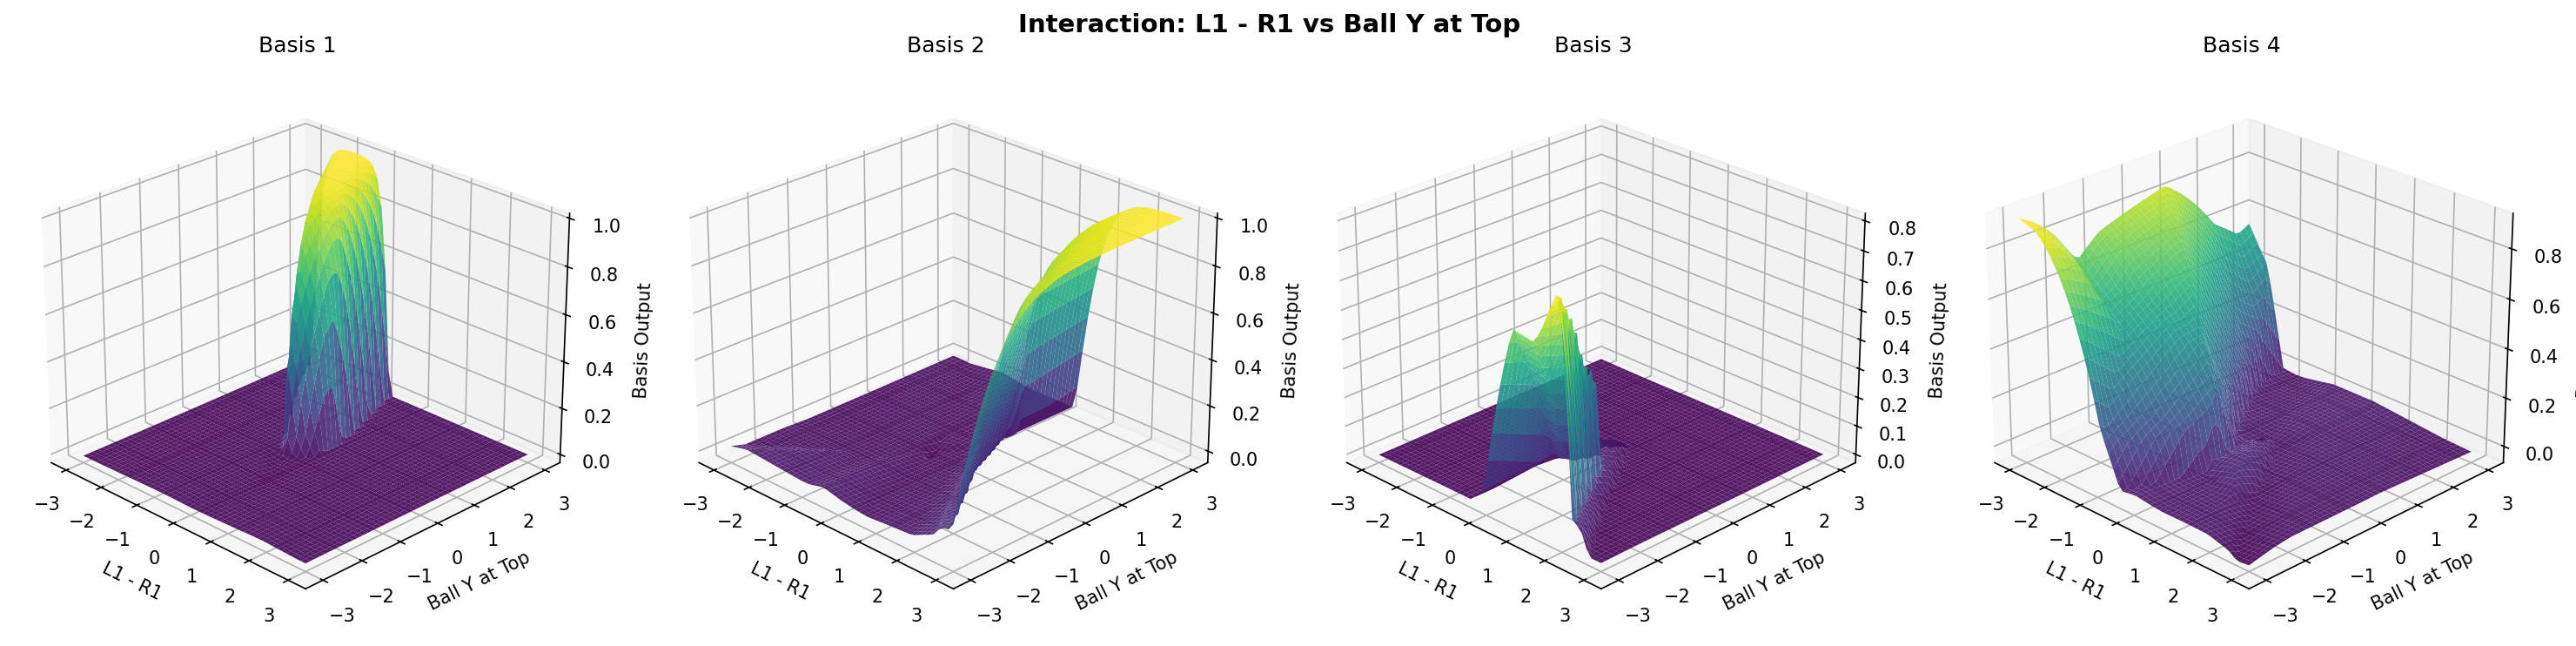

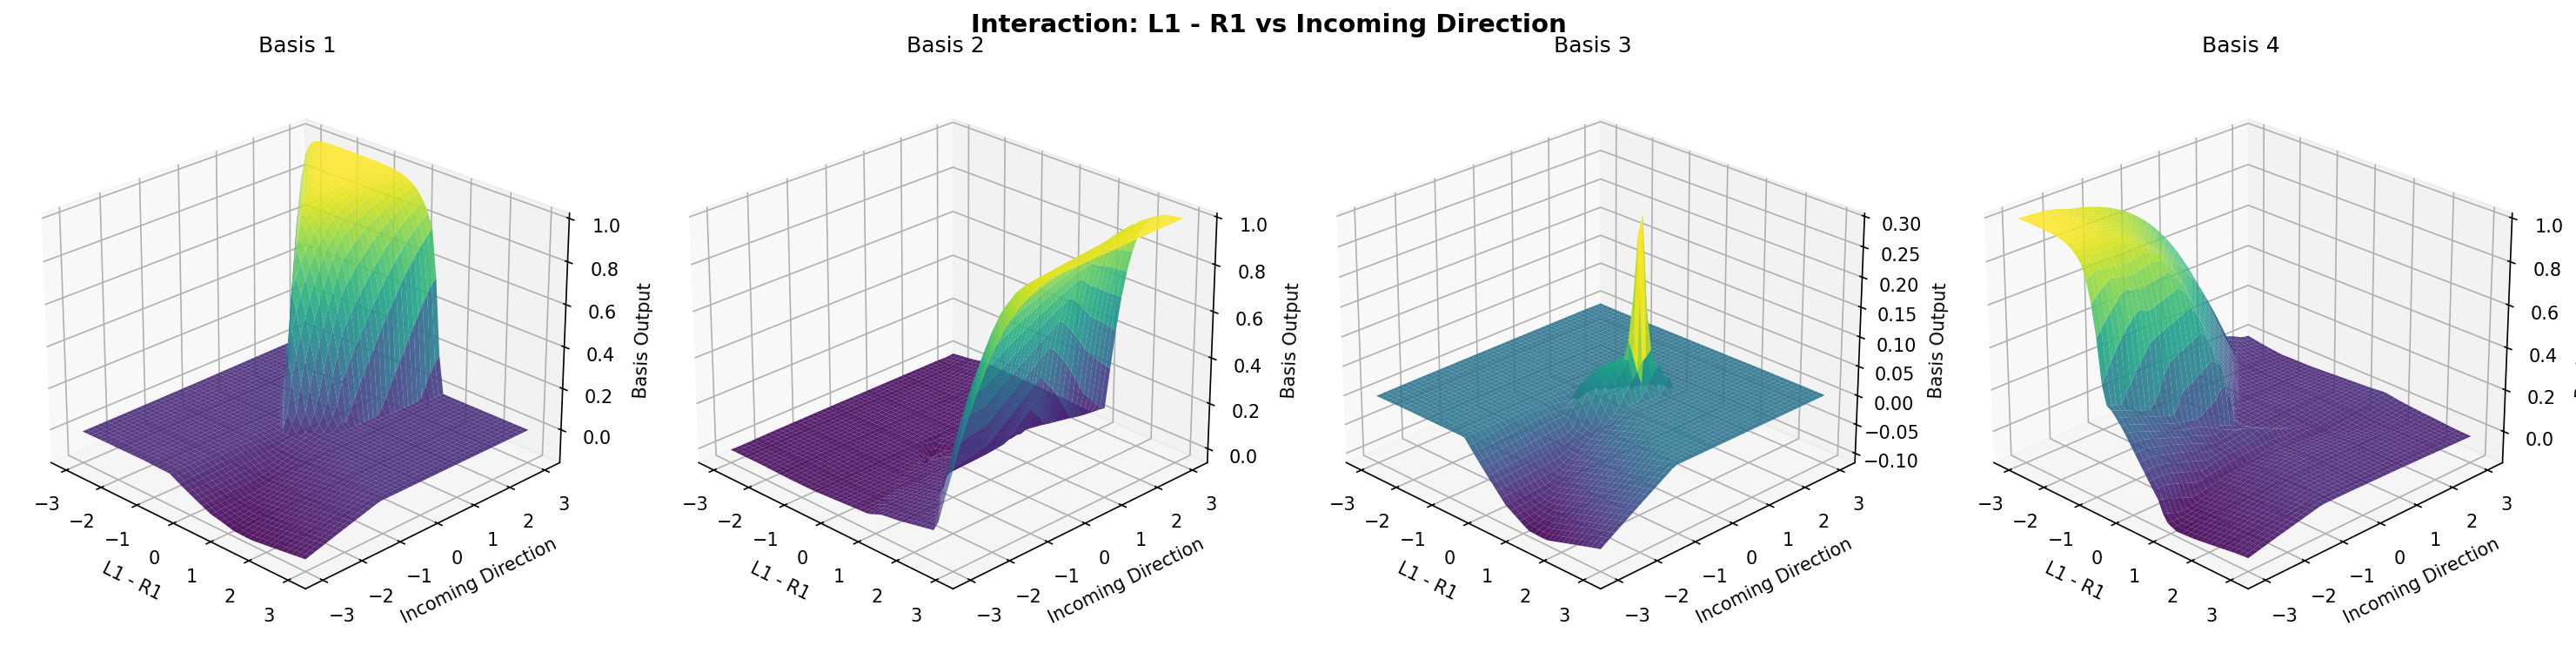

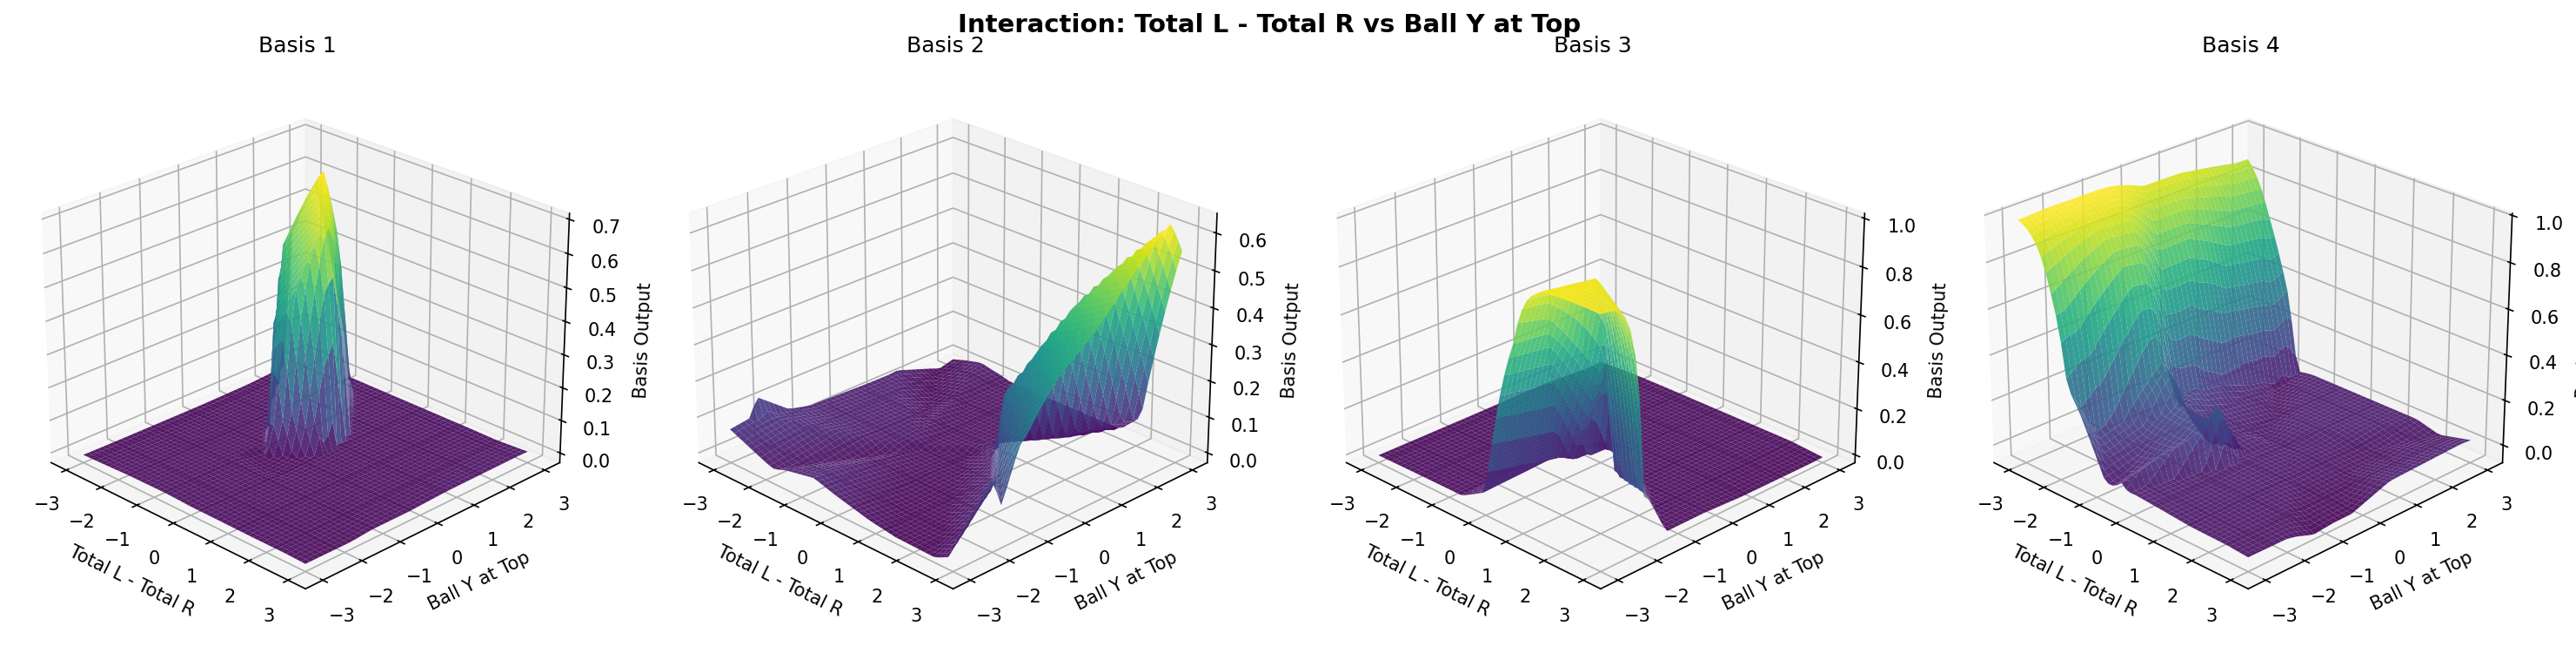

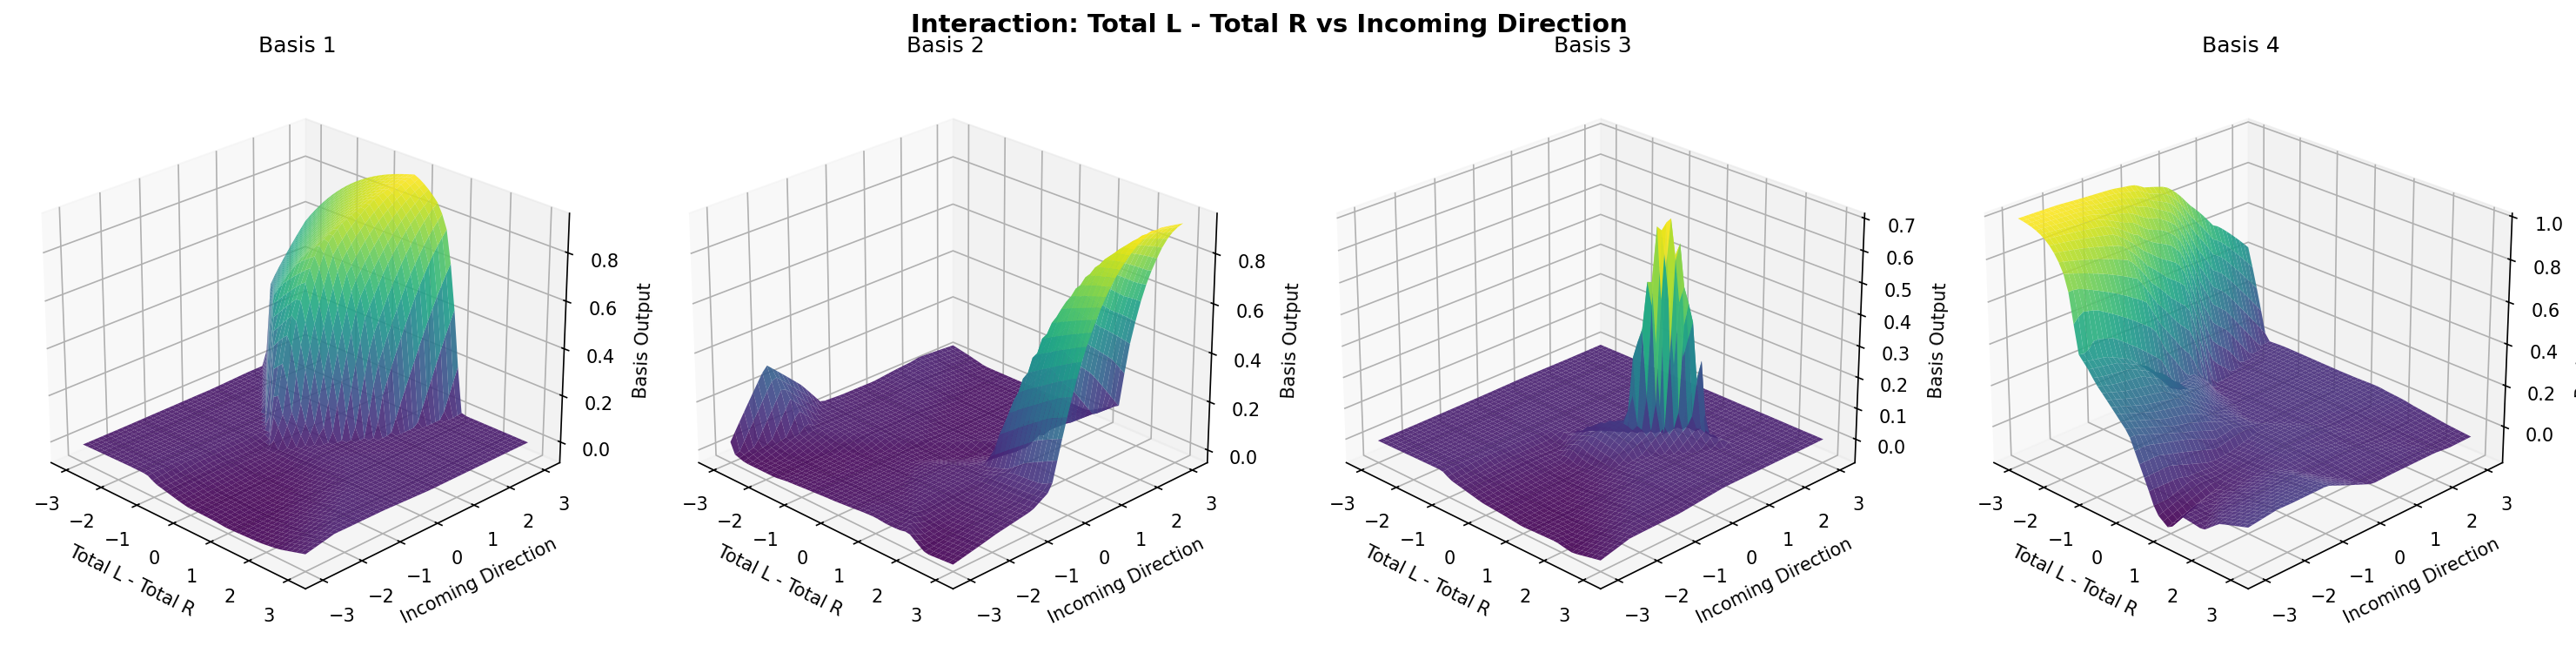

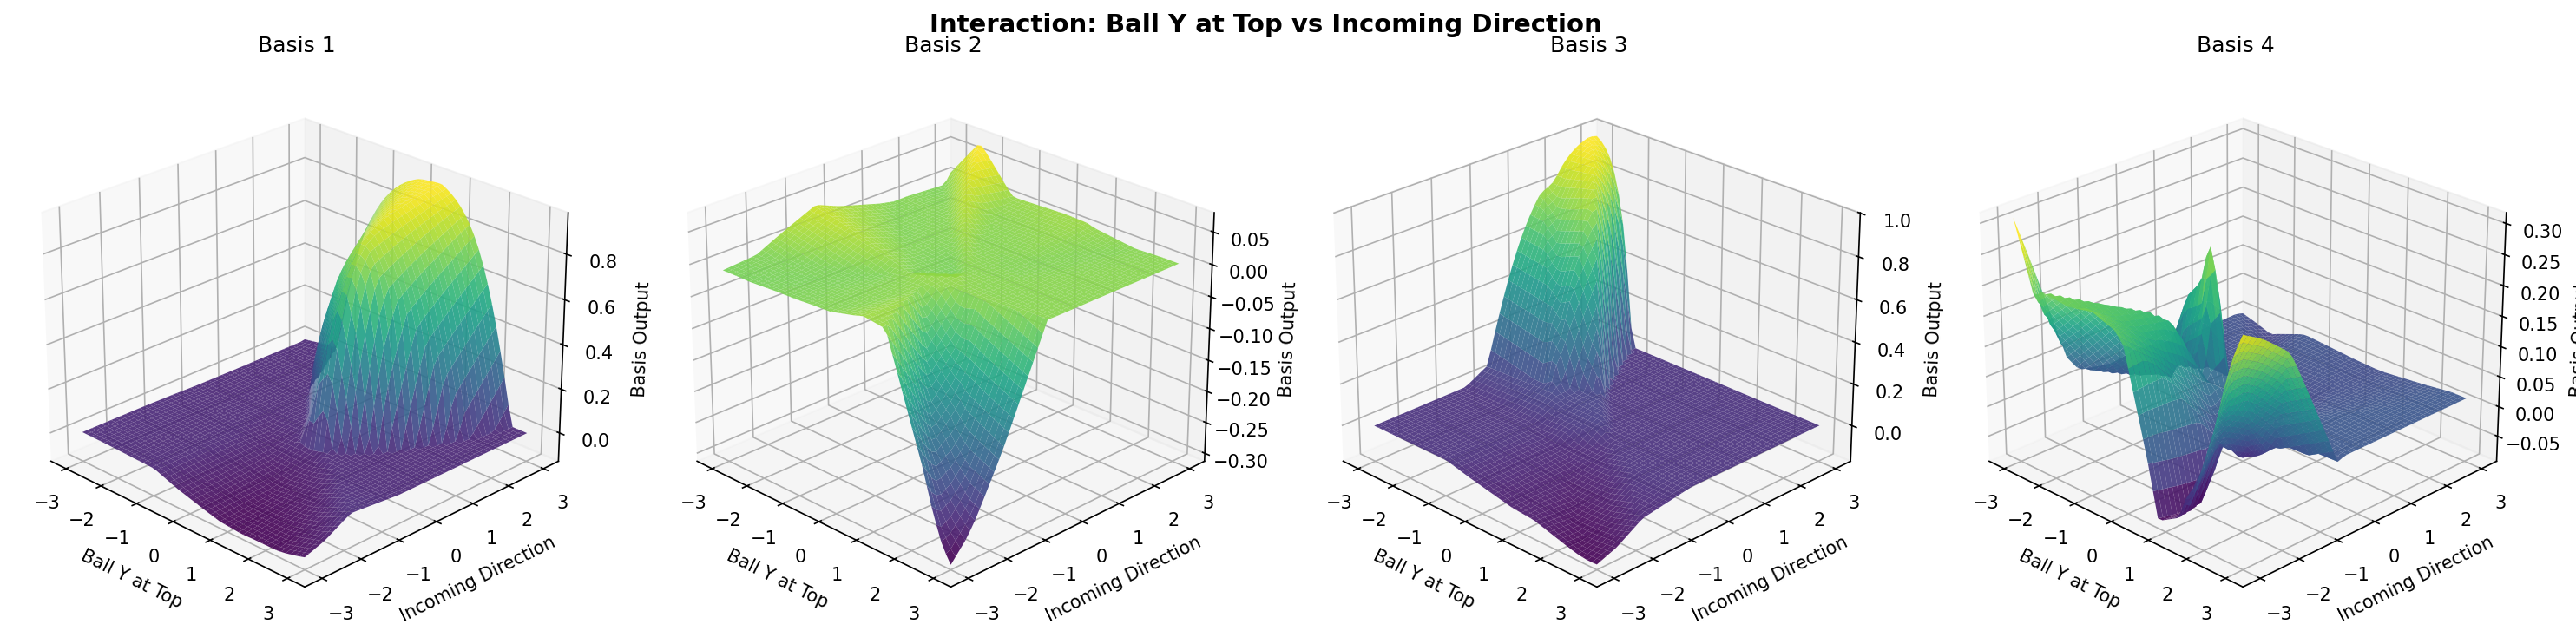

In [60]:
feature_labels = ["L1 - R1", "Total L - Total R", "Ball Y at Top", "Incoming Direction"]
plot_3d_basis_sweeps(trained_model, num_features=4, feature_names=feature_labels)